In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.model_Twin import(TwinFiLMUNetTiny_SpatialMoE)
from seq.preprocessing import cams_hourly_raw_csi_from_15min,match_one_to_one_nearest,band_indices_from_cams_night_windows, save_bands_filtered_by_idx
from seq.prepare_syn import predict_csi_from_X_npz,replace_csi,plot_csi_24h,continuity_metrics_cams_pred_csi

In [3]:
raw_hourly_npz = cams_hourly_raw_csi_from_15min(
    "Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",
    years=(2021, 2023),
)

Wrote: Data/CAMS/csi_cams_hourly_raw_2021_2023.npz
samples: 26269 | range: 2021-01-01T11:00 -> 2023-12-31T23:00
data channels: 0=GHI, 1=GHIcs, 2=CSI


In [ ]:
cams = np.load("Data/CAMS/csi_cams_hourly_raw_2021_2023.npz")
ghi_cs = cams["data"][:, 1]                
night = np.all(ghi_cs == 0, axis=(1,2))    

In [4]:
import numpy as np

def check_csi_ch2_night_by_csghi(npz_path, csghi_ch=1, night_thresh=0.0, eps=1e-6):
    npz = np.load(npz_path)
    data = npz["data"].astype(np.float32)   # (N,C,H,W)
    t_utc = npz["time"]                     # (N,) datetime64[m] UTC

    N, C, H, W = data.shape
    csi = data[:, 2]
    csghi = data[:, csghi_ch]

    night_pix = (csghi <= night_thresh)
    night_count = int(night_pix.sum())
    total = int(csi.size)

    full_night_frames = int(night_pix.reshape(N, -1).all(axis=1).sum())
    print("N:", N, "C:", C, "H,W:", (H, W))
    print("UTC time:", t_utc[0], "->", t_utc[-1])
    print("csghi_ch:", csghi_ch, "night_thresh:", night_thresh)
    print("full-night frames:", full_night_frames, "/", N)
    print("night pixels:", night_count, "/", total, f"({night_count/total:.3f})")

    if night_count == 0:
        print("No night pixels found. csghi_ch or threshold is wrong.")
        return

    night_vals = csi[night_pix]
    print("CSI@night strict zero frac:", float((night_vals == 0.0).mean()))
    print(f"CSI@night |<= {eps} frac:", float((np.abs(night_vals) <= eps).mean()))
    print("CSI@night min/max:", float(night_vals.min()), float(night_vals.max()))
    print("CSI@night p99 abs:", float(np.percentile(np.abs(night_vals), 99)))

    # show one worst case with its UTC timestamp
    abs_night = np.abs(csi) * night_pix
    flat = int(abs_night.reshape(-1).argmax())
    ti = flat // (H * W)
    r = (flat % (H * W)) // W
    c = (flat % (H * W)) % W
    print("Worst night |CSI| at:", (ti, r, c),
          "CSI=", float(csi[ti, r, c]),
          "csGHI=", float(csghi[ti, r, c]),
          "UTC=", t_utc[ti])


In [8]:
check_csi_ch2_night_by_csghi("Data/CAMS/csi_cams_hourly_raw_2021_2023.npz", csghi_ch=1)


N: 26269 C: 3 H,W: (50, 50)
UTC time: 2021-01-01T11:00 -> 2023-12-31T23:00
csghi_ch: 1 night_thresh: 0.0
full-night frames: 12719 / 26269
night pixels: 32003739 / 65672500 (0.487)
CSI@night strict zero frac: 1.0
CSI@night |<= 1e-06 frac: 1.0
CSI@night min/max: 0.0 0.0
CSI@night p99 abs: 0.0
Worst night |CSI| at: (0, 0, 0) CSI= 0.0 csGHI= 0.0 UTC= 2021-01-01T11:00


In [ ]:
out = match_one_to_one_nearest(
    "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",
    "Data/bands/combined_15ch_full.npz",
    band_time_key="time_min",
    tol_min=10,   # set False if you want all CAMS times
)

In [ ]:
dt = (out["cams_time"].astype("datetime64[m]").astype("int64")
    - out["band_time"].astype("datetime64[m]").astype("int64"))

print("max abs minutes:", np.max(np.abs(dt)))
print("unique bands:", len(np.unique(out["band_idx"])), " / ", len(out["band_idx"]))
print("unique cams :", len(np.unique(out["cams_idx"])), " / ", len(out["cams_idx"]))


In [ ]:
bands_path = "Data/bands/combined_15ch_full.npz"
cams_path  = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"

# WITHOUT boundary: only night windows
idx_night = band_indices_from_cams_night_windows(
    out, cams_path, bands_path,
    band_time_key="time_min",
    cams_cs_channel=1,
    tol_min=10,
    add_boundary=False,
)

save_bands_filtered_by_idx(
    bands_path,
    "Data/bands/15ch_full_night.npz",
    idx_night,
)

# WITH boundary: widen each night window by +/- 1 CAMS hour (time-based), then reselect bands by time
idx_night_wide = band_indices_from_cams_night_windows(
    out, cams_path, bands_path,
    band_time_key="time_min",
    cams_cs_channel=1,
    tol_min=10,
    add_boundary=True,   # widens by +/-60 min (plus tol_min)
    cams_step_min=60,
)

save_bands_filtered_by_idx(
    bands_path,
    "Data/bands/15ch_full_night_wide.npz",
    idx_night_wide,
)


In [ ]:
# 1) build X for the bands dataset you want to use for prediction
shape, out = build_band_tensor_with_elevation(
    bands_npz_name="Data/bands/15ch_full_night_wide.npz",
    elevation_npz_name="Data/elevation/hk_geom_50x50.npz",
    bands_used=[
        'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
        'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
    ],
    output_path="Data/output/X_for_inference2_wide.npz",
)

In [2]:
import numpy as np
band = np.load("Data/output/X_for_inference2_wide.npz") # or X_for_inference2
t = band["time_hourly"]
print(t.dtype, t[:5])
print("min/max:", t.min(), t.max())
print("unique diffs (first 10):", np.unique(np.diff(t.astype(np.int64)))[:10])


int64 [26824910 26824920 26824930 26824940 26824950]
min/max: 26824910 28401070
unique diffs (first 10): [ 10  20  30  90 320 580 640 650 700 710]


In [3]:
# load model (CSI-only output)
PATH = "Model_checkpoint/best_moe_easy_good.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

m2 = TwinFiLMUNetTiny_SpatialMoE(feature_size=64, K=2, gate_temp=0.5).to(device)
ckpt = torch.load(PATH, map_location=device)
sd = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
m2.load_state_dict(sd)

<All keys matched successfully>

In [6]:
# ----------------- USAGE -----------------
X_HOURLY = "Data/output/X_for_inference2_wide.npz"  # keys: data, time_hourly
CAMS_IN  = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"
CAMS_OUT = "Data/CAMS/csi_cams_hourly_pred_2021_2023_wide.npz"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# model already loaded as m2 in your snippet
t_pred, y_pred = predict_csi_from_X_npz(
    X_HOURLY, model=m2, device=device,
    batch_size=64, x_key="data", t_key="time_hourly"
)

In [7]:
replace_csi(
    cams_npz_in=CAMS_IN,
    cams_npz_out="Data/CAMS/csi_cams_hourly_pred_2021_2023_wide.npz",
    t_pred=t_pred,
    y_pred=y_pred,
    tol_min=30, 
    overwrite_mode="pred"
)

Wrote: Data/CAMS/csi_cams_hourly_pred_2021_2023_wide.npz
Matched preds: 14892/26269 (tol=±30 min, offset=0 min)
Overwrote (mode=pred): 14892/26269
Match delta(min) stats: min=0, mean=0.063, max=30


'Data/CAMS/csi_cams_hourly_pred_2021_2023_wide.npz'

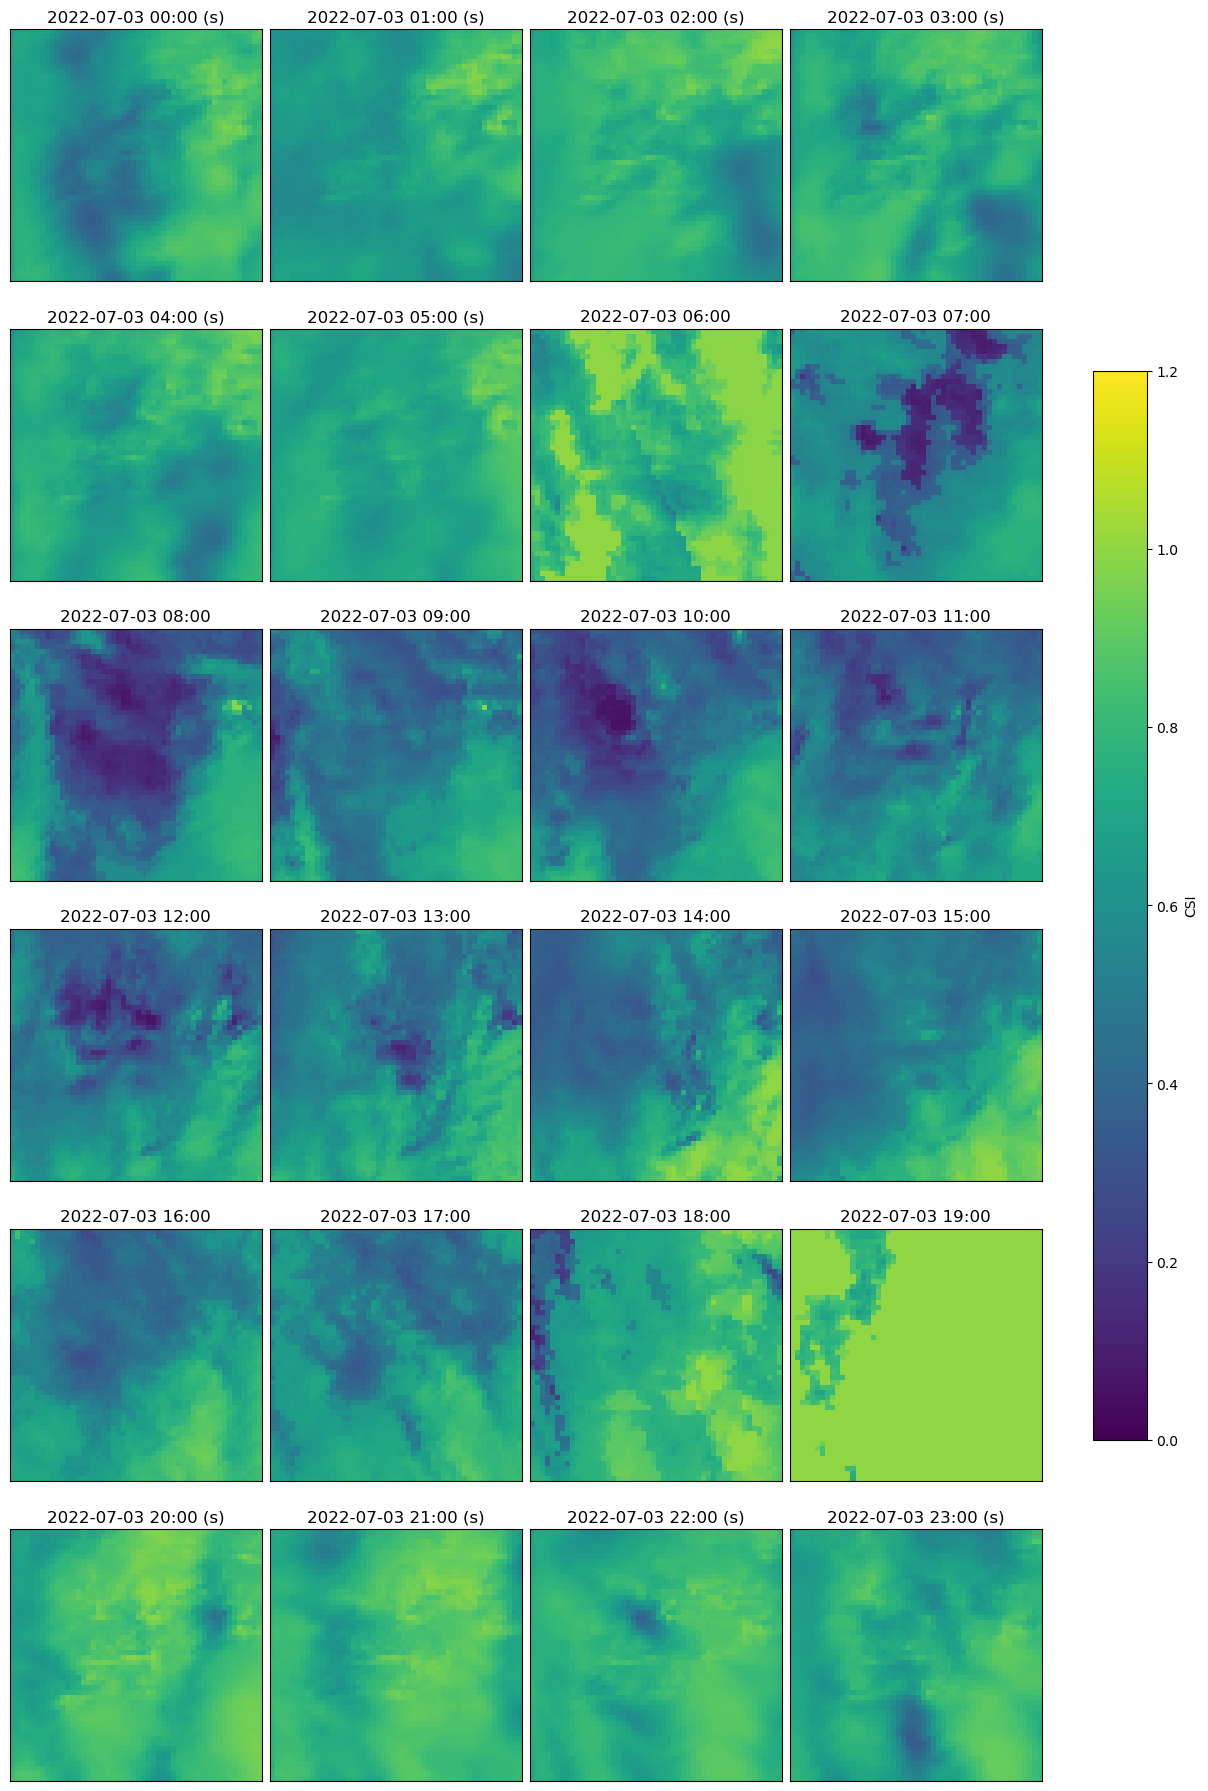

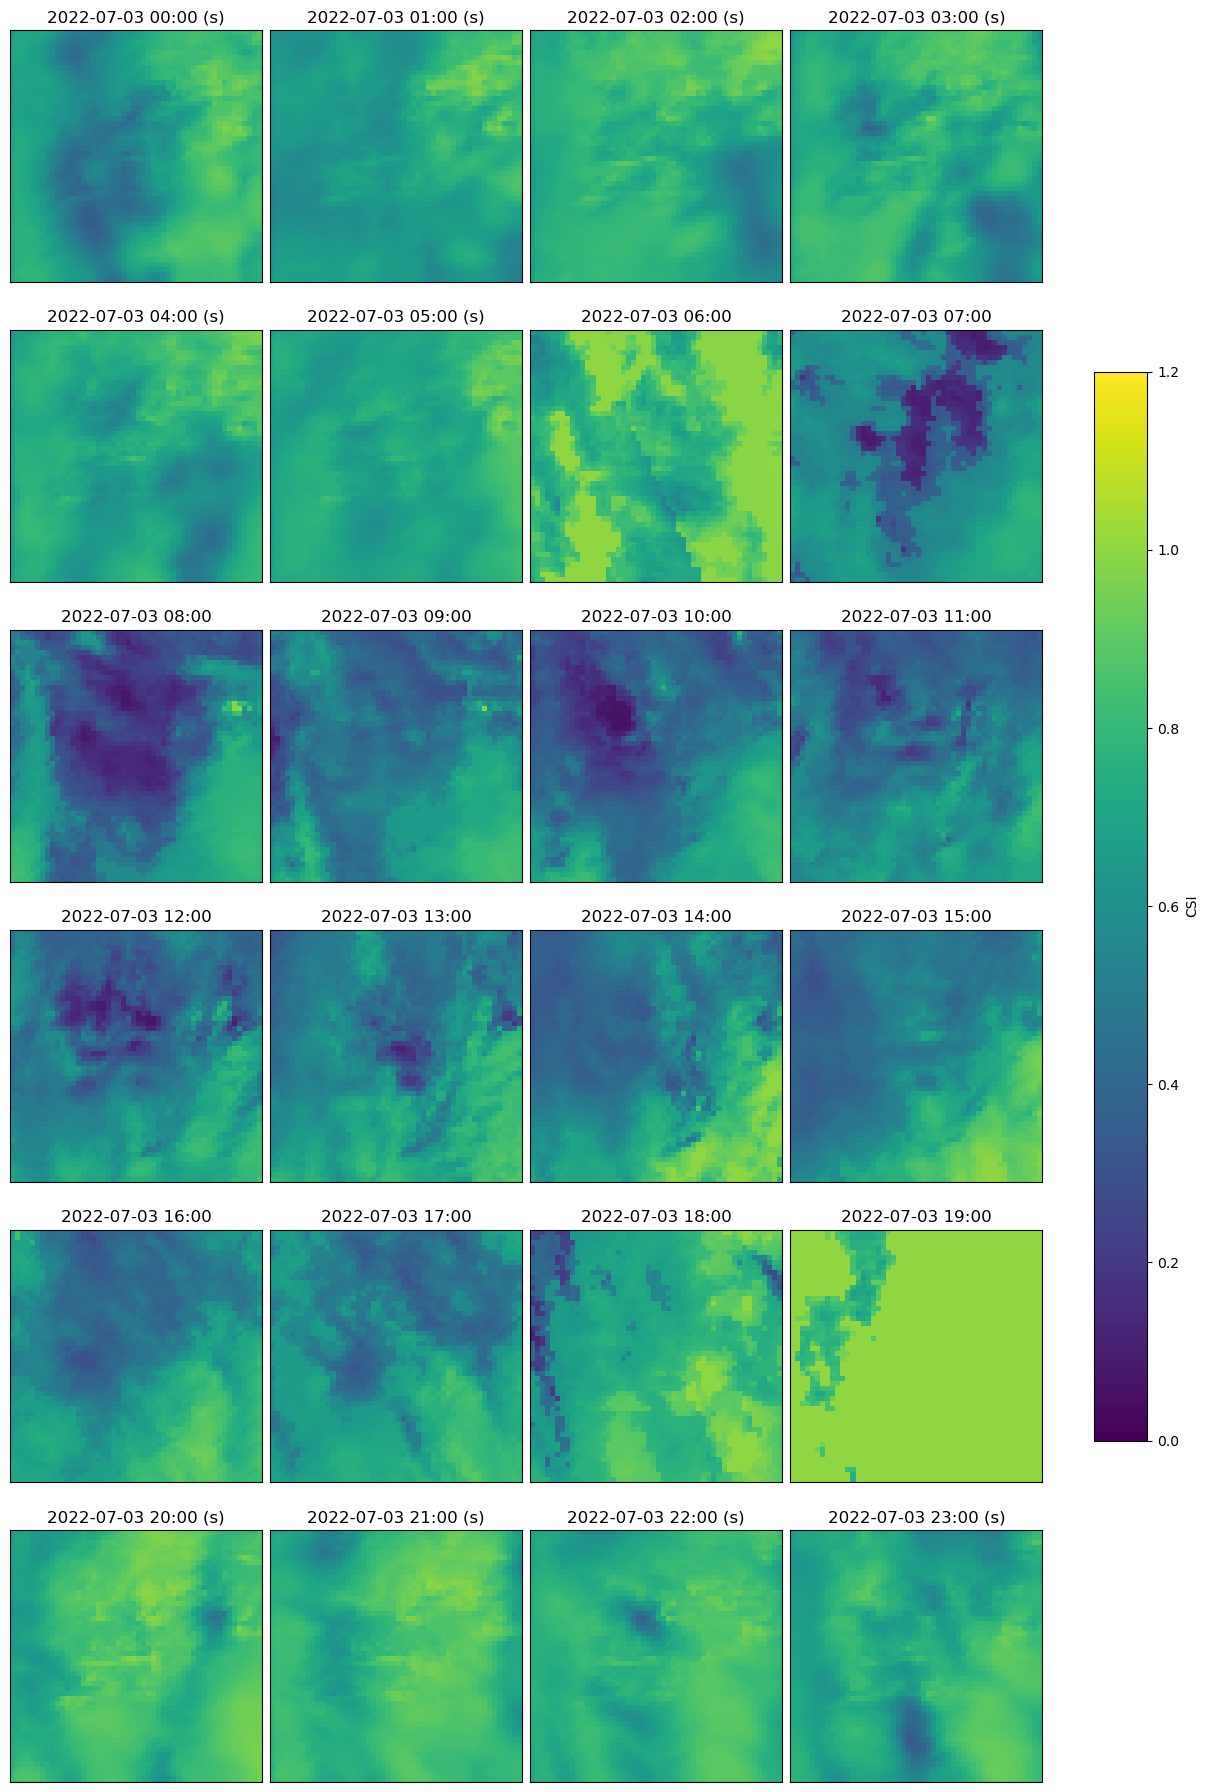

In [4]:
plot_csi_24h(
    pred_npz_path="Data/CAMS/csi_cams_hourly_pred_2021_2023.npz",
    orig_npz_path="Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",  # original before overwrite
    start_time_hk="2022-07-03T00:00:00",
)

In [ ]:
plot_csi_24h(
    pred_npz_path="Data/CAMS/csi_cams_hourly_pred_2021_2023_wide.npz",
    orig_npz_path="Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",  # original before overwrite
    start_time_hk="2022-07-03T00:00:00",
)

In [ ]:
m = continuity_metrics_cams_pred_csi(
    pred_npz_path="Data/CAMS/csi_cams_hourly_pred_2021_2023.npz",
    raw_npz_path="Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",
    top_k=50,
    diff_eps=1e-6,
)

=== Top suspicious hourly transitions (by jump_score) ===
[17926] 2023-01-18T09:00:00.000000000 -> 2023-01-18T10:00:00.000000000  jump=8.17  l2=0.9951  l1=0.9943  corr=0.005  type=day|raw -> day|raw
[13392] 2022-07-13T11:00:00.000000000 -> 2022-07-13T12:00:00.000000000  jump=8.17  l2=0.9942  l1=0.9937  corr=0.000  type=day|raw -> night|raw
[17927] 2023-01-18T10:00:00.000000000 -> 2023-01-18T11:00:00.000000000  jump=8.06  l2=0.9812  l1=0.9807  corr=-0.015  type=day|raw -> night|pred
[10323] 2022-03-07T14:00:00.000000000 -> 2022-03-07T15:00:00.000000000  jump=8.03  l2=0.9789  l1=0.9787  corr=0.000  type=night|pred -> night|raw
[22703] 2023-08-05T10:00:00.000000000 -> 2023-08-05T11:00:00.000000000  jump=8.02  l2=0.9790  l1=0.9777  corr=0.015  type=day|raw -> day|raw
[10328] 2022-03-07T19:00:00.000000000 -> 2022-03-07T20:00:00.000000000  jump=8.01  l2=0.9770  l1=0.9768  corr=0.000  type=night|raw -> night|pred
[  407] 2021-01-18T10:00:00.000000000 -> 2021-01-18T11:00:00.000000000  jump=7.9

In [ ]:
m2 = continuity_metrics_cams_pred_csi(
   pred_npz_path="Data/CAMS/csi_cams_hourly_pred_2021_2023_wide.npz",
    raw_npz_path="Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",
    top_k=50,
    diff_eps=1e-6,
)

=== Top suspicious hourly transitions (by jump_score) ===
[13392] 2022-07-13T11:00:00.000000000 -> 2022-07-13T12:00:00.000000000  jump=9.04  l2=0.9942  l1=0.9937  corr=0.000  type=day|raw -> night|raw
[10323] 2022-03-07T14:00:00.000000000 -> 2022-03-07T15:00:00.000000000  jump=8.89  l2=0.9789  l1=0.9787  corr=0.000  type=night|pred -> night|raw
[10327] 2022-03-07T18:00:00.000000000 -> 2022-03-07T19:00:00.000000000  jump=8.86  l2=0.9761  l1=0.9758  corr=0.000  type=night|raw -> night|pred
[13402] 2022-07-13T21:00:00.000000000 -> 2022-07-13T22:00:00.000000000  jump=8.73  l2=0.9661  l1=0.9574  corr=0.000  type=night|raw -> day|raw
[ 7068] 2021-10-22T23:00:00.000000000 -> 2021-10-23T00:00:00.000000000  jump=7.74  l2=0.8629  l1=0.8618  corr=0.025  type=day|pred -> day|raw
[20254] 2023-04-25T09:00:00.000000000 -> 2023-04-25T10:00:00.000000000  jump=7.15  l2=0.7919  l1=0.7845  corr=-0.175  type=day|raw -> day|pred
[ 7044] 2021-10-21T23:00:00.000000000 -> 2021-10-22T00:00:00.000000000  jump=7.

In [7]:
raw = np.load("Data/CAMS/csi_cams_hourly_raw_2021_2023.npz")
pred = np.load("Data/CAMS/csi_cams_hourly_pred_2021_2023.npz")
pred_wide = np.load("Data/CAMS/csi_cams_hourly_pred_2021_2023_wide.npz")

In [8]:
raw["data"].shape,pred["data"].shape,pred_wide["data"].shape

((26269, 3, 50, 50), (26269, 3, 50, 50), (26269, 3, 50, 50))

In [9]:
raw["time"]

array(['2021-01-01T11:00', '2021-01-01T12:00', '2021-01-01T13:00', ...,
       '2023-12-31T21:00', '2023-12-31T22:00', '2023-12-31T23:00'],
      shape=(26269,), dtype='datetime64[m]')

In [10]:
pred["time"]

array(['2021-01-01T11:00', '2021-01-01T12:00', '2021-01-01T13:00', ...,
       '2023-12-31T21:00', '2023-12-31T22:00', '2023-12-31T23:00'],
      shape=(26269,), dtype='datetime64[m]')

In [11]:
pred_wide["time"]

array(['2021-01-01T11:00', '2021-01-01T12:00', '2021-01-01T13:00', ...,
       '2023-12-31T21:00', '2023-12-31T22:00', '2023-12-31T23:00'],
      shape=(26269,), dtype='datetime64[m]')

In [12]:
import numpy as np

def segment_by_csghi_zero(raw_data, clearsky_ch=1, transition_window=30, stride=1, eps=0.0):
    """
    不做任何去噪/平滑。
    仅用 clear-sky GHI 判定：
      - night: cs_mean <= eps   (eps=0 表示严格等于0；eps>0 是浮点容差)
      - day:   cs_mean > eps
      - dusk:  day -> night 的边界附近 window
      - dawn:  night -> day 的边界附近 window

    返回每个 segment 的 pair_mask（长度 T-stride）。
    """
    x = np.asarray(raw_data, dtype=np.float32)
    T, C, H, W = x.shape

    cs = x[:, clearsky_ch, :, :].mean(axis=(1,2))  # (T,)
    cs = np.nan_to_num(cs, nan=0.0)

    is_night = cs <= eps
    is_day = ~is_night

    # 真正的边界点
    day_to_night = np.where(is_day[:-1] & is_night[1:])[0] + 1   # sunset-like
    night_to_day = np.where(is_night[:-1] & is_day[1:])[0] + 1   # sunrise-like

    dusk_frame = np.zeros(T, dtype=bool)
    dawn_frame = np.zeros(T, dtype=bool)
    w = int(transition_window)

    for t0 in day_to_night:
        dusk_frame[max(0, t0 - w): min(T, t0 + w)] = True
    for t0 in night_to_day:
        dawn_frame[max(0, t0 - w): min(T, t0 + w)] = True

    # 纯 day/night：排除交界窗口，避免重叠
    pure_day = is_day & (~dusk_frame) & (~dawn_frame)
    pure_night = is_night & (~dusk_frame) & (~dawn_frame)

    def pair_mask_from_frame_mask(fmask):
        return fmask[:-stride] & fmask[stride:]

    seg = {
        "day": pair_mask_from_frame_mask(pure_day),
        "night": pair_mask_from_frame_mask(pure_night),
        "dusk": pair_mask_from_frame_mask(dusk_frame),
        "dawn": pair_mask_from_frame_mask(dawn_frame),
        # meta/debug
        "eps": float(eps),
        "day_ratio": float(is_day.mean()),
        "night_ratio": float(is_night.mean()),
        "day_to_night_count": int(day_to_night.size),
        "night_to_day_count": int(night_to_day.size),
        "cs_min": float(cs.min()),
        "cs_max": float(cs.max()),
        "cs_nonzero_ratio": float((cs > 0).mean()),
    }
    return seg


In [13]:
seg = segment_by_csghi_zero(raw["data"], clearsky_ch=1, transition_window=1, stride=1, eps=0.0)

print("transitions:", seg["day_to_night_count"], seg["night_to_day_count"])
print("n_pairs day/night/dusk/dawn:",
      seg["day"].sum(), seg["night"].sum(), seg["dusk"].sum(), seg["dawn"].sum())


transitions: 1094 1095
n_pairs day/night/dusk/dawn: 10267 9435 1094 1095


In [14]:
seg = segment_by_csghi_zero(
    raw["data"],
    clearsky_ch=1,
    transition_window=1,  # hourly 用 1 或 2
    stride=1,
    eps=0.0
)


In [15]:
import numpy as np
import pandas as pd

def coherence_summary_by_segments(
    raw, pred, pred_wide,
    key="data",
    csghi_ch=1,          # CS-GHI channel index (0-based). you said channel 1
    csi_ch=-1,           # CSI channel index, default last channel
    eps_cs=0.0,          # night if csghi_mean <= eps_cs (eps=0 means strict zero)
    transition_window=1, # HOURLY data: 1 or 2 (hours). This is ±window frames.
    stride=1,
    clip_csi=(0, 1),
    low_threshold=0.75,
    pooled_range=True,   # use pooled p95-p05 across datasets per segment
    eps_range=1e-6
):
    """
    Returns:
      summary_df: dataset x segment table with n_pairs, mean, median, p10, min, low_ratio
      meta: sanity info (ratios, transition counts, n_pairs per segment)
      scores: dict[(dataset, segment)] -> scores array length (T-stride,) with NaNs outside segment
    """

    # --------- helpers ----------
    def _summarize(scores):
        s = np.asarray(scores, dtype=np.float32)
        f = s[np.isfinite(s)]
        if f.size == 0:
            return {"n_pairs": 0, "mean": np.nan, "median": np.nan, "p10": np.nan, "min": np.nan,
                    "low_ratio(<thr)": np.nan}
        return {
            "n_pairs": int(f.size),
            "mean": float(np.mean(f)),
            "median": float(np.median(f)),
            "p10": float(np.percentile(f, 10)),
            "min": float(np.min(f)),
            "low_ratio(<thr)": float(np.mean(f < low_threshold)),
        }

    def _robust_range(vals):
        v = np.asarray(vals, dtype=np.float32)
        v = v[np.isfinite(v)]
        if v.size < 100:
            return np.nan
        p05 = np.percentile(v, 5)
        p95 = np.percentile(v, 95)
        return float(max(p95 - p05, eps_range))

    def _pair_mask_from_frame_mask(fmask, stride=1):
        fmask = np.asarray(fmask, dtype=bool)
        return fmask[:-stride] & fmask[stride:]

    def _segment_masks_from_csghi(data):
        x = np.asarray(data, dtype=np.float32)
        T, C, H, W = x.shape
        cs = x[:, csghi_ch, :, :].mean(axis=(1, 2))
        cs = np.nan_to_num(cs, nan=0.0)

        is_night = cs <= eps_cs
        is_day = ~is_night

        # transitions at frame t0 (t0-1 -> t0)
        day_to_night = np.where(is_day[:-1] & is_night[1:])[0] + 1
        night_to_day = np.where(is_night[:-1] & is_day[1:])[0] + 1

        w = int(transition_window)
        dusk_frame = np.zeros(T, dtype=bool)
        dawn_frame = np.zeros(T, dtype=bool)

        for t0 in day_to_night:
            dusk_frame[max(0, t0 - w): min(T, t0 + w + 1)] = True
        for t0 in night_to_day:
            dawn_frame[max(0, t0 - w): min(T, t0 + w + 1)] = True

        # remove transitions from pure day/night to avoid overlap
        trans_union = dusk_frame | dawn_frame
        pure_day = is_day & (~trans_union)
        pure_night = is_night & (~trans_union)

        seg = {
            "day": _pair_mask_from_frame_mask(pure_day, stride=stride),
            "night": _pair_mask_from_frame_mask(pure_night, stride=stride),
            "dusk": _pair_mask_from_frame_mask(dusk_frame, stride=stride),
            "dawn": _pair_mask_from_frame_mask(dawn_frame, stride=stride),
            # debug/meta
            "_T": int(T),
            "_cs_min": float(cs.min()),
            "_cs_max": float(cs.max()),
            "_day_ratio": float(is_day.mean()),
            "_night_ratio": float(is_night.mean()),
            "_day_to_night_count": int(day_to_night.size),
            "_night_to_day_count": int(night_to_day.size),
        }
        return seg

    def _coherence_scores(data, pair_mask, range_ref):
        x = np.asarray(data, dtype=np.float32)
        T, C, H, W = x.shape
        ch = x[:, csi_ch, :, :]  # (T,H,W)
        if clip_csi is not None:
            ch = np.clip(ch, clip_csi[0], clip_csi[1])

        out = np.full((T - stride,), np.nan, dtype=np.float32)
        idx = np.where(pair_mask)[0]
        if idx.size == 0:
            return out

        a = ch[idx]
        b = ch[idx + stride]
        mae = np.nanmean(np.abs(b - a), axis=(1, 2))
        s = 1.0 - mae / max(float(range_ref), eps_range)
        out[idx] = np.clip(s, 0.0, 1.0).astype(np.float32)
        return out

    # --------- main ----------
    raw_data = raw[key]
    pred_data = pred[key]
    wide_data = pred_wide[key]

    # segmentation based ONLY on raw cs-ghi (same timeline)
    seg = _segment_masks_from_csghi(raw_data)
    T = seg["_T"]

    # meta sanity counts
    meta = {
        "T": T,
        "stride": stride,
        "transition_window(frames)": int(transition_window),
        "eps_cs": float(eps_cs),
        "cs_min": seg["_cs_min"],
        "cs_max": seg["_cs_max"],
        "day_ratio": seg["_day_ratio"],
        "night_ratio": seg["_night_ratio"],
        "day_to_night_count": seg["_day_to_night_count"],
        "night_to_day_count": seg["_night_to_day_count"],
        "n_pairs_day": int(seg["day"].sum()),
        "n_pairs_night": int(seg["night"].sum()),
        "n_pairs_dusk": int(seg["dusk"].sum()),
        "n_pairs_dawn": int(seg["dawn"].sum()),
    }

    datasets = [("raw", raw_data), ("pred", pred_data), ("pred_wide", wide_data)]
    rows = []
    scores = {}

    for segment in ["day", "night", "dusk", "dawn"]:
        pm = seg[segment]

        # choose a shared range_ref for fair comparison
        if pooled_range:
            idx_t = np.where(pm)[0]
            if idx_t.size == 0:
                range_ref = np.nan
            else:
                frame_idx = np.unique(np.concatenate([idx_t, idx_t + stride]))
                pooled_vals = []
                for _, data in datasets:
                    v = np.asarray(data, dtype=np.float32)[frame_idx, csi_ch, :, :]
                    if clip_csi is not None:
                        v = np.clip(v, clip_csi[0], clip_csi[1])
                    pooled_vals.append(v.reshape(-1))
                range_ref = _robust_range(np.concatenate(pooled_vals, axis=0))
        else:
            # not recommended: each dataset own range (less comparable)
            range_ref = np.nan

        for name, data in datasets:
            rr = range_ref
            if (not np.isfinite(rr)) or rr <= 0:
                # fallback: compute from itself in this segment
                idx_t = np.where(pm)[0]
                if idx_t.size > 0:
                    frame_idx = np.unique(np.concatenate([idx_t, idx_t + stride]))
                    v = np.asarray(data, dtype=np.float32)[frame_idx, csi_ch, :, :]
                    if clip_csi is not None:
                        v = np.clip(v, clip_csi[0], clip_csi[1])
                    rr = _robust_range(v.reshape(-1))
                else:
                    rr = np.nan

            sc = _coherence_scores(data, pm, rr) if np.isfinite(rr) else np.full((T - stride,), np.nan, np.float32)
            scores[(name, segment)] = sc
            summ = _summarize(sc)
            rows.append({
                "dataset": name,
                "segment": segment,
                "range_ref(p95-p05)": float(rr) if np.isfinite(rr) else np.nan,
                **summ,
                "threshold": float(low_threshold),
                "transition_window": int(transition_window),
            })

    summary_df = pd.DataFrame(rows).sort_values(["segment", "dataset"]).reset_index(drop=True)
    return summary_df, meta, scores


In [22]:
summary_df, meta, scores = coherence_summary_by_segments(
    raw, pred, pred_wide,
    key="data",
    csghi_ch=1,
    csi_ch=-1,           # CSI 在最后一个 channel
    eps_cs=0.0,          # CS-GHI 夜晚严格为0
    transition_window=1, # hourly：1或2
    stride=1,
    clip_csi=(0,1),
    low_threshold=0.75
)

In [19]:
summary_df.head()

,dataset,segment,range_ref(p95-p05),n_pairs,mean,median,p10,min,low_ratio(<thr),threshold,transition_window
0,pred,dawn,1.000000,4378,0.841829,0.873217,0.679682,0.039908,0.188899,0.75,2
1,pred_wide,dawn,1.000000,4378,0.874238,0.907785,0.736141,0.042554,0.112152,0.75,2
2,raw,dawn,1.000000,4378,0.724133,0.850595,0.083444,0.000000,0.336912,0.75,2
3,pred,day,0.896873,6985,0.878124,0.881701,0.772626,0.497122,0.061990,0.75,2
4,pred_wide,day,0.896873,6985,0.878124,0.881701,0.772626,0.497122,0.061990,0.75,2


In [24]:
summary_df[(summary_df["dataset"] =="pred") | (summary_df["dataset"] =="raw")]

,dataset,segment,range_ref(p95-p05),n_pairs,mean,median,p10,min,low_ratio(<thr),threshold,transition_window
0,pred,dawn,1.000000,2189,0.787038,0.815611,0.576860,0.039908,0.329831,0.75,1
2,raw,dawn,1.000000,2189,0.517458,0.626954,0.023565,0.000000,0.627684,0.75,1
3,pred,day,0.895594,9173,0.875473,0.879121,0.770055,0.496404,0.065300,0.75,1
5,raw,day,0.895594,9173,0.875473,0.879121,0.770055,0.496404,0.065300,0.75,1
6,pred,dusk,1.000000,2188,0.855107,0.912190,0.630631,0.006329,0.171389,0.75,1
8,raw,dusk,1.000000,2188,0.619367,0.999800,0.018480,0.000000,0.469378,0.75,1
9,pred,night,0.991123,8341,0.935799,0.945669,0.867825,0.012558,0.005395,0.75,1
11,raw,night,0.991123,8341,1.000000,1.000000,1.000000,1.000000,0.000000,0.75,1


In [25]:
import numpy as np
import pandas as pd

def predictive_validity_persistence_3h(
    raw, pred, pred_wide,
    key="data",
    csghi_ch=1,     # CS-GHI channel index
    csi_ch=-1,      # CSI channel index (last)
    horizon=3,      # hours, since hourly data
    eps_cs=0.0,     # night if cs_mean <= eps_cs
    clip_csi=(0,1)
):
    R = np.asarray(raw[key], dtype=np.float32)
    P = np.asarray(pred[key], dtype=np.float32)
    W = np.asarray(pred_wide[key], dtype=np.float32)

    T, C, H, Wd = R.shape
    assert horizon >= 1 and horizon < T

    # day/night mask from CS-GHI (raw)
    cs = R[:, csghi_ch].mean(axis=(1,2))
    cs = np.nan_to_num(cs, nan=0.0)
    is_night = cs <= eps_cs
    is_day = ~is_night

    # truth: raw CSI (only evaluated on day indices)
    y_true = R[:, csi_ch]
    if clip_csi is not None:
        y_true = np.clip(y_true, clip_csi[0], clip_csi[1])

    # build three input CSI series (day uses raw CSI to isolate night effect)
    raw_csi = y_true.copy()

    pred_csi = P[:, csi_ch]
    wide_csi = W[:, csi_ch]
    if clip_csi is not None:
        pred_csi = np.clip(pred_csi, clip_csi[0], clip_csi[1])
        wide_csi = np.clip(wide_csi, clip_csi[0], clip_csi[1])

    # baseline: night CSI = 0 (uninformative), day CSI = raw
    x_base = raw_csi.copy()
    x_base[is_night] = 0.0

    # pred-fill: night CSI = pred, day CSI = raw
    x_pred = raw_csi.copy()
    x_pred[is_night] = pred_csi[is_night]

    # pred_wide-fill: night CSI = pred_wide, day CSI = raw
    x_wide = raw_csi.copy()
    x_wide[is_night] = wide_csi[is_night]

    def eval_variant(x, name):
        # predict day frames only, using persistence horizon
        t = np.arange(horizon, T)
        day_t = t[is_day[horizon:]]                 # t where target is day
        if day_t.size == 0:
            return None

        yhat = x[day_t - horizon]                  # (N,H,W)
        y = y_true[day_t]                          # (N,H,W)

        err = yhat - y
        mae = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err**2)))

        # dawn-3h subset: target is day but input time is night (t-h is night)
        dawn_mask = is_night[day_t - horizon]
        dawn_t = day_t[dawn_mask]
        if dawn_t.size > 0:
            yhat_d = x[dawn_t - horizon]
            y_d = y_true[dawn_t]
            err_d = yhat_d - y_d
            mae_d = float(np.mean(np.abs(err_d)))
            rmse_d = float(np.sqrt(np.mean(err_d**2)))
            n_dawn = int(dawn_t.size)
        else:
            mae_d = np.nan
            rmse_d = np.nan
            n_dawn = 0

        # full-grid error map (per pixel MAE) for ALL-DAY and DAWN-3H
        mae_map_day = np.mean(np.abs(err), axis=0)  # (H,W)
        if dawn_t.size > 0:
            mae_map_dawn = np.mean(np.abs(err_d), axis=0)
        else:
            mae_map_dawn = np.full((H,Wd), np.nan, dtype=np.float32)

        return {
            "variant": name,
            "n_day": int(day_t.size),
            "MAE_day": mae,
            "RMSE_day": rmse,
            "n_dawn3h": n_dawn,
            "MAE_dawn3h": mae_d,
            "RMSE_dawn3h": rmse_d,
            "mae_map_day": mae_map_day,
            "mae_map_dawn3h": mae_map_dawn,
        }

    res_base = eval_variant(x_base, "baseline_night0")
    res_pred = eval_variant(x_pred, "night_pred")
    res_wide = eval_variant(x_wide, "night_pred_wide")

    # tabular summary + skill scores vs baseline
    rows = []
    for r in [res_base, res_pred, res_wide]:
        rows.append({k: r[k] for k in ["variant","n_day","MAE_day","RMSE_day","n_dawn3h","MAE_dawn3h","RMSE_dawn3h"]})
    df = pd.DataFrame(rows)

    # skill score (higher is better)
    b_mae_day = res_base["MAE_day"]
    b_mae_dawn = res_base["MAE_dawn3h"]
    df["skill_day(MAE)"] = 1.0 - df["MAE_day"] / b_mae_day
    df["skill_dawn3h(MAE)"] = 1.0 - df["MAE_dawn3h"] / b_mae_dawn if np.isfinite(b_mae_dawn) else np.nan

    maps = {
        "baseline": {"day": res_base["mae_map_day"], "dawn3h": res_base["mae_map_dawn3h"]},
        "pred":     {"day": res_pred["mae_map_day"], "dawn3h": res_pred["mae_map_dawn3h"]},
        "wide":     {"day": res_wide["mae_map_day"], "dawn3h": res_wide["mae_map_dawn3h"]},
    }

    meta = {
        "T": int(T),
        "H": int(H),
        "W": int(Wd),
        "horizon": int(horizon),
        "day_ratio": float(is_day.mean()),
        "night_ratio": float(is_night.mean()),
        "eps_cs": float(eps_cs),
    }
    return df, maps, meta


In [26]:
df, maps, meta = predictive_validity_persistence_3h(raw, pred, pred_wide, horizon=3, csghi_ch=1, csi_ch=-1)



In [27]:
df

,variant,n_day,MAE_day,RMSE_day,n_dawn3h,MAE_dawn3h,RMSE_dawn3h,skill_day(MAE),skill_dawn3h(MAE)
0,baseline_night0,13550,0.309550,0.452463,3283,0.714106,0.782603,0.000000,0.000000
1,night_pred,13550,0.194673,0.290163,3283,0.239969,0.339127,0.371111,0.663959
2,night_pred_wide,13550,0.194673,0.290163,3283,0.239969,0.339127,0.371111,0.663959


In [54]:
R = raw["data"]; P = pred["data"]; W = pred_wide["data"]
cs = R[:,1].mean(axis=(1,2))
night = cs == 0
print("max abs diff on night:", np.max(np.abs(P[night,-1] - W[night,-1])))


max abs diff on night: 0.999959


In [55]:
import numpy as np

def sanity_check_inputs_for_eval(raw, pred, pred_wide, key="data", csghi_ch=1, csi_ch=-1, horizon=3, eps_cs=0.0):
    R = raw[key].astype(np.float32)
    P = pred[key].astype(np.float32)
    W = pred_wide[key].astype(np.float32)

    cs = R[:, csghi_ch].mean(axis=(1,2))
    cs = np.nan_to_num(cs, nan=0.0)
    is_night = cs <= eps_cs
    is_day = ~is_night

    T = R.shape[0]
    t = np.arange(horizon, T)
    day_t = t[is_day[horizon:]]  # targets in day

    # dawn3h: targets in day but inputs are night
    dawn_t = day_t[is_night[day_t - horizon]]

    # compare pred vs wide on the ACTUAL INPUT frames used for dawn3h
    if dawn_t.size > 0:
        inp_idx = dawn_t - horizon
        diff = np.abs(P[inp_idx, csi_ch] - W[inp_idx, csi_ch])
        print("dawn3h count:", dawn_t.size)
        print("max abs diff on USED input frames:", float(np.max(diff)))
        print("mean abs diff on USED input frames:", float(np.mean(diff)))
    else:
        print("No dawn3h samples under this definition.")

sanity_check_inputs_for_eval(raw, pred, pred_wide, horizon=3)


dawn3h count: 3283
max abs diff on USED input frames: 7.468461990356445e-05
mean abs diff on USED input frames: 2.183400127364621e-09


In [58]:
import numpy as np
import pandas as pd

def pv_boundary_first_day_plus3(raw, pred, pred_wide, key="data",
                               csghi_ch=1, csi_ch=-1, eps_cs=0.0, clip=(0,1), horizon=3):
    R = raw[key].astype(np.float32)
    P = pred[key].astype(np.float32)
    W = pred_wide[key].astype(np.float32)

    T = R.shape[0]

    cs = R[:, csghi_ch].mean(axis=(1,2))
    cs = np.nan_to_num(cs, nan=0.0)
    is_night = cs <= eps_cs
    is_day = ~is_night

    y = R[:, csi_ch]
    if clip is not None:
        y = np.clip(y, clip[0], clip[1])

    # night->day transition gives first day frame t0
    night_to_day = np.where(is_night[:-1] & is_day[1:])[0] + 1  # t0

    # evaluate t = t0 + horizon (so input is t0)
    t_eval = night_to_day + horizon

    # ---- boundary-safe filtering ----
    valid = (t_eval >= 0) & (t_eval < T)
    t_eval = t_eval[valid]

    # require target is day
    t_eval = t_eval[is_day[t_eval]]

    # persistence input index
    inp = t_eval - horizon
    valid2 = (inp >= 0) & (inp < T)
    t_eval = t_eval[valid2]
    inp = inp[valid2]

    if t_eval.size == 0:
        return pd.DataFrame([{
            "set": f"first_day_frame+{horizon}h",
            "n": 0,
            "MAE_pred": np.nan,
            "MAE_pred_wide": np.nan,
            "RMSE_pred": np.nan,
            "RMSE_pred_wide": np.nan,
            "delta_MAE(pred - wide)": np.nan
        }])

    y_true = y[t_eval]

    yhat_pred = P[inp, csi_ch]
    yhat_wide = W[inp, csi_ch]

    if clip is not None:
        yhat_pred = np.clip(yhat_pred, clip[0], clip[1])
        yhat_wide = np.clip(yhat_wide, clip[0], clip[1])

    def mae(a,b): return float(np.mean(np.abs(a-b)))
    def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))

    out = pd.DataFrame([{
        "set": f"first_day_frame+{horizon}h",
        "n": int(t_eval.size),
        "MAE_pred": mae(yhat_pred, y_true),
        "MAE_pred_wide": mae(yhat_wide, y_true),
        "RMSE_pred": rmse(yhat_pred, y_true),
        "RMSE_pred_wide": rmse(yhat_wide, y_true),
    }])
    out["delta_MAE(pred - wide)"] = out["MAE_pred"] - out["MAE_pred_wide"]
    return out


In [60]:
print(pv_boundary_first_day_plus3(raw, pred, pred_wide, horizon=3))


                  set     n  MAE_pred  MAE_pred_wide  RMSE_pred  \
0  first_day_frame+3h  1094    0.2434       0.226028   0.353474   

   RMSE_pred_wide  delta_MAE(pred - wide)  
0        0.312839                0.017373  
